Here's a high-level overview of the flow of the code:

1. Import necessary libraries: This includes libraries for handling arrays (NumPy), image processing (OpenCV, skimage), medical image processing (nibabel), machine learning (Keras), and others.

2. Define helper functions: These are functions that will be used throughout the code for various tasks such as plotting images and contours, converting images to RGB, etc.

3. Define paths for the datasets: These are the paths to the directories where the MRI images and masks for Site A and Site B are stored.

4. Define Dataset and Dataloader classes: These classes are used to represent the dataset and to load data from the dataset in batches, respectively.

5. Load the MRI images and masks: This is done using the nibabel library. The images are then preprocessed (e.g., normalized, converted to binary masks, etc.) and low-information slices are removed.

6. Split the dataset into training, validation, and test sets: This is done using the split-folders library.

7. Convert the 3D MRI images to 2D slices and save them: This involves converting the single-channel images to pseudo RGB images, resizing the images, and saving them as 2D slices.

8. Load the data using the Dataset and Dataloader classes: This involves creating instances of the Dataset class for the training, validation, and test sets, and then creating instances of the Dataloader class to load data from these datasets in batches.

9. Train the model: This involves defining the model architecture, compiling the model, defining callbacks, and then training the model using the training and validation data.

10. Evaluate the model: This involves using the trained model to make predictions on the test data and then evaluating the performance of the model.

11. Save the model: This involves saving the trained model so that it can be used later without having to retrain it.

12. Plot the training history: This involves plotting the training and validation loss and accuracy over each epoch to visualize how the model's performance changed during training.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install git+https://github.com/qubvel/segmentation_models

**Resolution of AttributeError in Google Colab**

Upon encountering an AttributeError when attempting to import the segmentation_models library in Google Colab, it is necessary to follow a corrective procedure. The AttributeError is as follows:

`AttributeError: module 'keras.utils' has no attribute 'generic_utils'`

To rectify this issue, the following steps are recommended:

**Locate the File**: click on the location of the the file specified in the error message. Typically, this file is found in the directory path

`"/usr/local/lib/python3.10/dist-packages/efficientnet/init.py".`

**Modify the Code**: Within the file, identify the line of code responsible for the AttributeError. Specifically, the line resembling the following structure:

`keras.utils.generic_utils.get_custom_objects().update(custom_objects)`

Here, the ".generic_utils" segment should be removed, resulting in the modified line:

`keras.utils.get_custom_objects().update(custom_objects)`

**Save Changes:** Once the code modification is performed, save the changes to the file.

**Restart Session:** To ensure the fix takes effect, restart the Colab session. This can be accomplished by navigating to the "Runtime" menu and selecting "Restart session".

**Verification:** After restarting the session,import the segmentation_models library once more. If the corrective actions were successful, the library should be imported without encountering the AttributeError.

In [3]:
import segmentation_models as sm

AttributeError: module 'keras.utils' has no attribute 'generic_utils'

In [2]:
!pip install split-folders

# Importing Libraries

In [3]:
import os
import numpy as np
import pandas as pd
import cv2
import nibabel as nib
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from skimage.transform import resize
import keras
from keras.utils import Sequence
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from tensorflow.keras.optimizers import Adam
import datetime
import splitfolders

# Data Preparation Module

## Automated Processing and Saving of MRI Images with Segmentation Masks

This section details an automated pipeline for processing MRI images and segmentation masks within a site-specific folder organization. It involves loading .nii.gz files, excluding slices with minimal information based on a set threshold, and saving the processed data in an organized manner.



*   Reading MRI data into NumPy arrays
*   Filtering out less informative slices to concentrate on significant data
*   Structuring the output to reflect the original dataset's organization

In [5]:
def read_nii(filepath):
    """Load a Nifti file and return a NumPy array."""
    nii_img = nib.load(filepath)
    img_array = nii_img.get_fdata()
    return img_array

def save_processed_images(file, mri_img, seg_img, save_dir, site_folder):
    """
    Save processed MRI images and segmentation masks, creating site-specific subdirectories.

    Parameters:
    - file: The filename of the MRI image.
    - mri_img: The processed MRI image data.
    - seg_img: The processed segmentation mask data.
    - save_dir: The base directory where processed images and masks will be saved.
    - site_folder: The site-specific folder name (e.g., "Site-A-RUNMC").
    """
    mri_save_dir = os.path.join(save_dir, site_folder, 'mri_images')
    seg_save_dir = os.path.join(save_dir, site_folder, 'mri_masks')

    os.makedirs(mri_save_dir, exist_ok=True)
    os.makedirs(seg_save_dir, exist_ok=True)

    mri_save_path = os.path.join(mri_save_dir, file.replace('.nii.gz', '.npy'))
    seg_save_path = os.path.join(seg_save_dir, file.replace('.nii.gz', '-seg.npy'))

    np.save(mri_save_path, mri_img)
    np.save(seg_save_path, seg_img)

def process_single_image(root, file, threshold, save_dir):
    """
    Process a single MRI image and its segmentation, filtering out low-info slices.
    Return the original and filtered shapes.
    """
    site_folder = os.path.basename(os.path.normpath(root))
    mri_path = os.path.join(root, file)
    segmentation_path = mri_path.replace('.nii.gz', '_segmentation.nii.gz')

    mri_img = read_nii(mri_path)
    seg_img = (read_nii(segmentation_path) > 0).astype(np.uint8)

    original_shape = mri_img.shape

    slice_info = np.mean(seg_img, axis=(0, 1))
    valid_slices = slice_info >= threshold

    filtered_mri_img = mri_img[:, :, valid_slices]
    filtered_seg_img = seg_img[:, :, valid_slices]

    filtered_shape = filtered_mri_img.shape

    save_processed_images(file, filtered_mri_img, filtered_seg_img, save_dir, site_folder)

    return original_shape, filtered_shape


def process_and_save_images(image_dir, save_dir, threshold=0.01):
    """
    Process all MRI images and segmentation masks in the given directory.
    Collects and returns shape information for comparison, separated by site.
    """
    data_by_site = {}

    for root, dirs, files in os.walk(image_dir):
        for file in files:
            if file.endswith('.nii.gz') and 'segmentation' not in file.lower():
                site_folder = os.path.basename(os.path.normpath(root))
                if site_folder not in data_by_site:
                    data_by_site[site_folder] = {'image_names': [], 'original_shapes': [], 'filtered_shapes': []}

                original_shape, filtered_shape = process_single_image(root, file, threshold, save_dir)

                data_by_site[site_folder]['image_names'].append(file)
                data_by_site[site_folder]['original_shapes'].append(original_shape)
                data_by_site[site_folder]['filtered_shapes'].append(filtered_shape)

    return data_by_site


In [ ]:
image_dir = '/content/drive/MyDrive/CV_MRI_Project_Folder/Prostate_Data_OG_Site_A_B/'
save_dir = '/content/drive/MyDrive/CV_MRI_Project_Folder/Processed_Prostate_Site_A_B_Data/Filtered_Slices_Images_SiteA_SiteB/'
process_and_save_images(image_dir, save_dir, threshold=0.01)


## Comparative Analysis of MRI Slice Counts Before and After Preprocessing by Site



In [4]:
def visualize_shape_comparison(site, image_names, original_shapes, filtered_shapes):
    indices = range(len(image_names))
    original_slice_counts = [shape[2] for shape in original_shapes]
    filtered_slice_counts = [shape[2] for shape in filtered_shapes]

    plt.figure(figsize=(12, 6))
    plt.bar(indices, original_slice_counts, width=0.4, label='Original Slice Count', alpha=0.7)
    plt.bar([i+0.4 for i in indices], filtered_slice_counts, width=0.4, label='Filtered Slice Count', alpha=0.7)
    plt.xlabel('Image Index')
    plt.ylabel('Slice Count')
    plt.title(f'Slice Count Before and After Processing for {site}')
    plt.xticks([i+0.2 for i in indices], image_names, rotation='vertical')
    plt.legend()
    plt.tight_layout()
    plt.show()

def visualize_distribution_comparison(data_by_site):
    # Prepare data for box plots
    for site, data in data_by_site.items():
        original_counts = [shape[2] for shape in data['original_shapes']]
        filtered_counts = [shape[2] for shape in data['filtered_shapes']]
        counts_diff = [o - f for o, f in zip(original_counts, filtered_counts)]

        df = pd.DataFrame({
            'Original Slice Count': original_counts,
            'Filtered Slice Count': filtered_counts,
            'Difference': counts_diff
        })

        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df)
        plt.title(f'Slice Count Distribution Before and After Processing - {site}')
        plt.ylabel('Slice Count')
        plt.xlabel('Condition')
        plt.tight_layout()
        plt.savefig(f'slice_count_distribution_{site}.png')  # Save as PNG
        plt.show()


In [5]:
import pandas as pd

def tabulate_shape_comparison(image_names, original_shapes, filtered_shapes):
    data = {
        "Image Name": image_names,
        "Original Slice Count": [shape[2] for shape in original_shapes],
        "Filtered Slice Count": [shape[2] for shape in filtered_shapes]
    }
    df = pd.DataFrame(data)
    return df


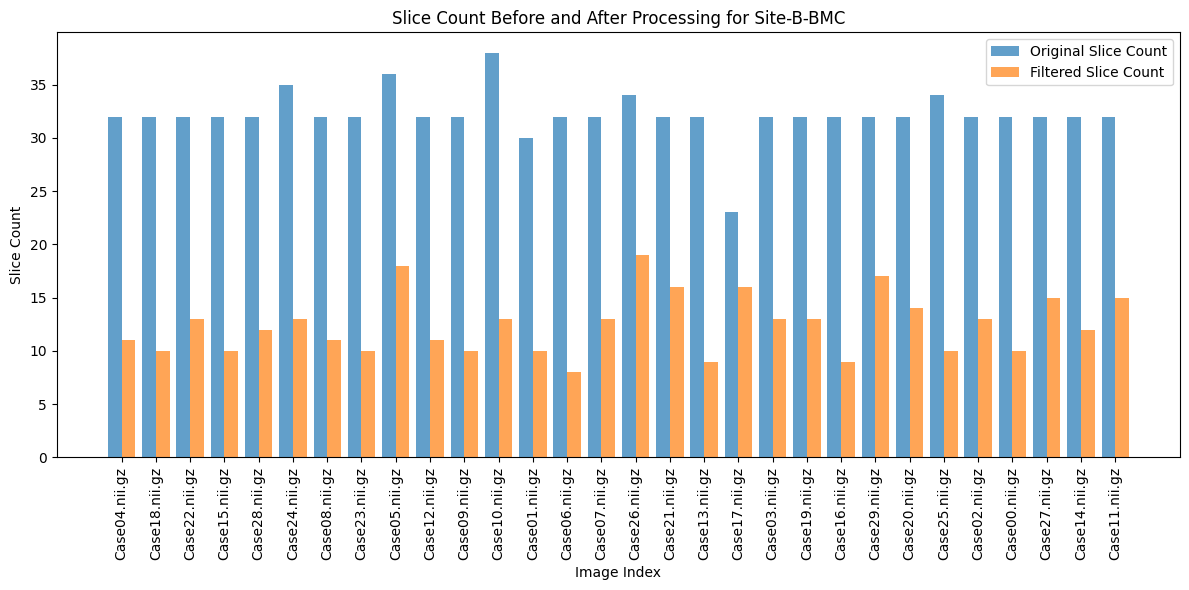

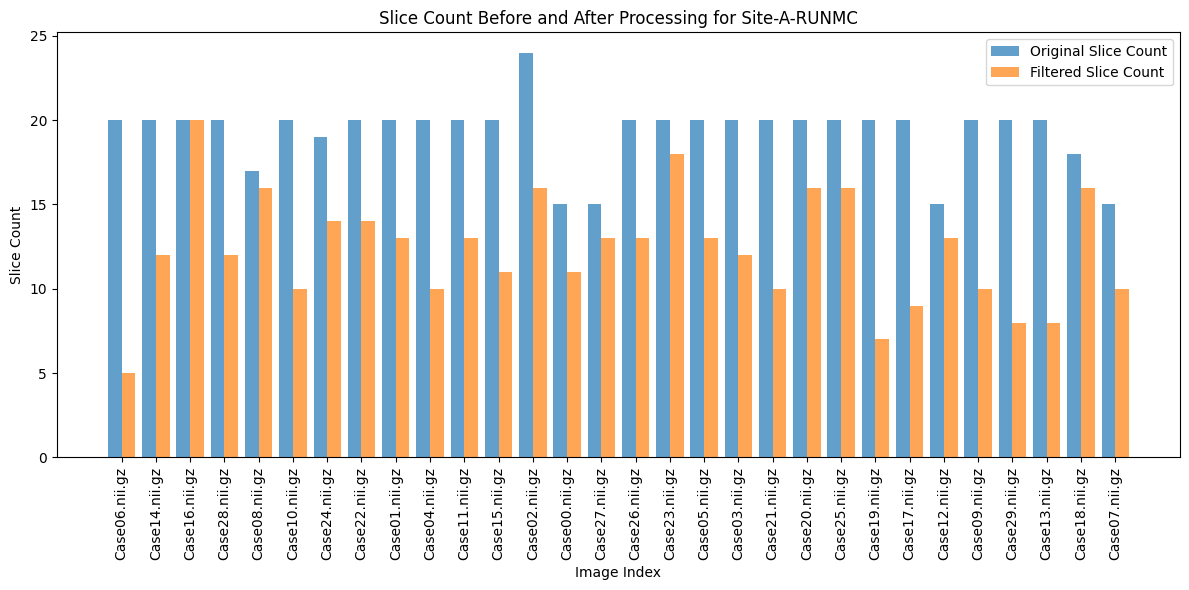

In [82]:
data_by_site = process_and_save_images(image_dir, save_dir, threshold=0.01)

for site, data in data_by_site.items():
    visualize_shape_comparison(
        site,
        data['image_names'],
        data['original_shapes'],
        data['filtered_shapes']
    )

These bar charts represent a comparative analysis of MRI slice counts that displays the original and filtered slice counts for various cases within Site-A-RUNMC and Site-B-BMC. Each case is represented by a pair of bars:

The blue bars represent the number of slices in the original image.
The orange bars represent the number of slices remaining after filtering based on your specified threshold.

Key Observations:

It is observed that there is a significant reduction in the number of slices across all cases after filtering, indicating that many slices were below the threshold and thus considered to have low information content.

The variance in the amount of reduction suggests that the distribution of informative slices is not uniform across the cases; some images retained more slices post-filtering than others.

These graphs provide a detailed case-by-case comparison but may become cluttered as the number of cases increases, making it harder to extract overall trends or averages.

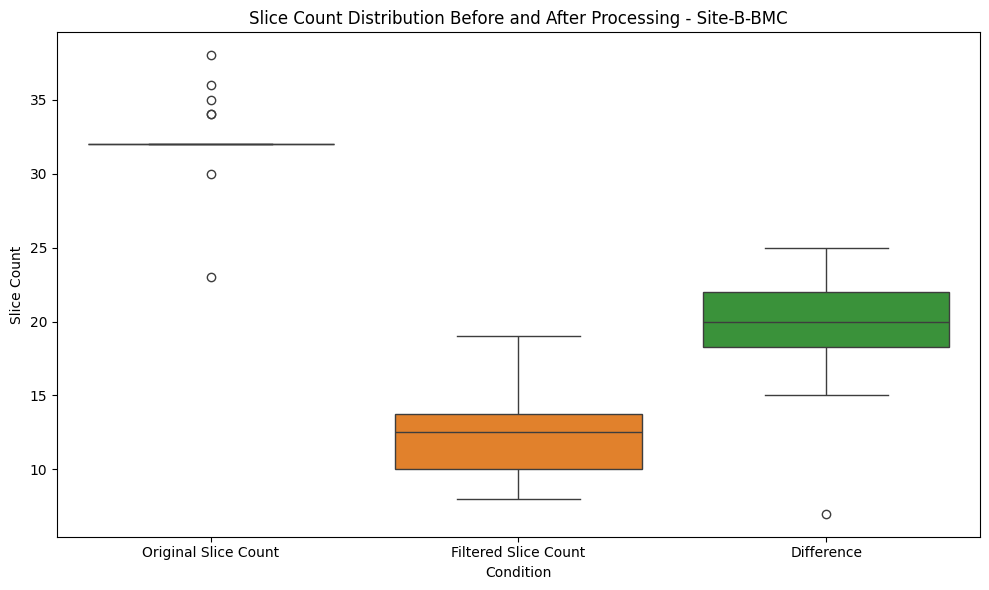

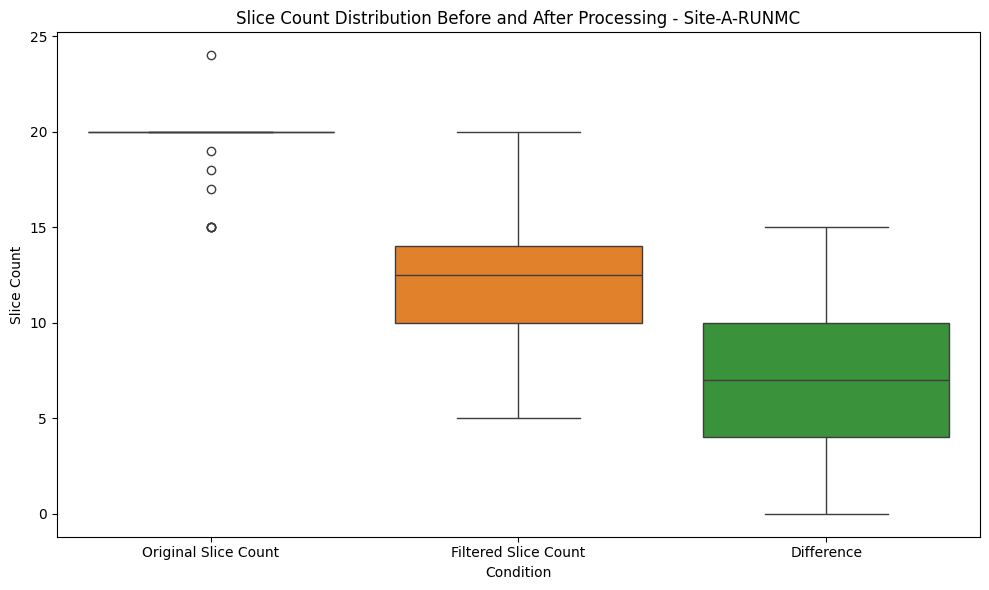

In [83]:
visualize_distribution_comparison(data_by_site)

These graphs are box and whisker plot illustrating the distribution of original and filtered slice counts for Site-A-RUNMC and Site-B-BMC with an additional box representing the difference in slice counts:

The orange box shows the distribution of the original slice counts.
The green box shows the distribution of the filtered slice counts.
There is a clear decrease in the median number of slices post-processing, as indicated by the position of the median line (middle line of the box) within each box.
The "Difference" box plot indicates the amount of reduction per case, with the median reduction marked by the line within the green box.

Key Observations:

The box plots summarize the central tendency and variability within each condition (original and filtered), showing the interquartile range (IQR) and any potential outliers (points outside of the whiskers).
This graph provides a succinct overview of the effect of filtering on the dataset without overwhelming details, making it suitable for conveying general trends in large datasets.
The presence of outliers in the "Original Slice Count" box plot suggests there are cases with significantly higher slice counts than the median.

### Evaluating the Efficacy of Data Preprocessing: Bar Charts vs. Box Plots

The bar chart is suitable for comparing individual cases but does not scale well with large datasets, while the box and whisker plot provides a high-level overview that scales better but offers less granularity. The box plot indicates the distribution, central tendency, and variability of the slice counts before and after processing, which is very useful for understanding the overall impact of the processing steps. The reduction in slices suggests that filtering is indeed removing less informative data, which is beneficial for model training.

## Preparing Prostate MRI Images for Segmentation Models Training

This section of the project handles essential data preprocessing tasks for a prostate MRI image segmentation task, tailored for a U-Net model or similar convolutional neural network architectures. The code automates several critical steps to prepare the dataset for model training:

**Directory Creation**: Automated creation of directories for processed data ensures a well-organized file structure, facilitating easier data management and access.

**Data Splitting**: Utilizes the splitfolders package to automatically partition the dataset into training, validation, and test sets based on a predefined ratio. This step is crucial for training robust machine learning models and evaluating their performance.

**Image Processing**: Converts MRI image slices to RGB format and resizes them to a uniform size, addressing requirements of CNNs that typically expect three-channel input images of a specific resolution.

**Data Verification**: Includes a function to verify that each image has a corresponding mask, ensuring data integrity and consistency across the dataset.

**Visualization**: Offers functionalities to visualize individual data samples and their segmentation masks, with an additional feature to overlay mask contours on the images. This aids in qualitative analysis of the data and preprocessing outcomes.

In [6]:
# Utility function to create directories
def create_dirs(dir_paths):
    for dir_path in dir_paths:
        os.makedirs(dir_path, exist_ok=True)

# Convert to RGB and resize images
def process_images(image_dir, mask_dir, output_image_dir, output_mask_dir, new_size):
    create_dirs([output_image_dir, output_mask_dir])

    for image_name in sorted(os.listdir(image_dir)):
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, image_name.replace('.npy', '-seg.npy'))

        # Load, convert to RGB, resize, and save images and masks
        image = np.load(image_path)
        mask = np.load(mask_path)
        for i in range(image.shape[2]):
            rgb_image = np.stack((image[:, :, i],) * 3, axis=-1)
            resized_img = resize(rgb_image, new_size, anti_aliasing=True, preserve_range=True)
            resized_mask = resize(mask[:, :, i], new_size, anti_aliasing=True, preserve_range=True)

            np.save(os.path.join(output_image_dir, f"{image_name.split('.')[0]}_slice_{i:02d}.npy"), resized_img)
            np.save(os.path.join(output_mask_dir, f"{image_name.split('.')[0]}_slice_{i:02d}_seg.npy"), resized_mask)

# Process and save all images
def process_all_images(base_input_dir, base_output_dir, new_size=(224, 224, 3)):
    for site_folder in sorted(os.listdir(base_input_dir)):
        for split_folder in ['train', 'val', 'test']:
            process_images(
                os.path.join(base_input_dir, site_folder, split_folder, 'mri_images'),
                os.path.join(base_input_dir, site_folder, split_folder, 'mri_masks'),
                os.path.join(base_output_dir, site_folder, split_folder, 'mri_images'),
                os.path.join(base_output_dir, site_folder, split_folder, 'mri_masks'),
                new_size
            )

# Function to automatically split data for all sites and create corresponding output directories
def split_data_for_all_sites(input_base_dir, output_base_dir, ratio=(0.7, 0.2, 0.1)):
    """
    Automatically splits data for all sites present in the input directory, creating corresponding output directories.

    Args:
    - input_base_dir: Base directory where input data for all sites is located.
    - output_base_dir: Base directory where output data for all sites will be stored.
    - ratio: Tuple indicating the split ratio for train, validation, and test sets.
    """
    # List all site directories in the input base directory
    for site_dir in os.listdir(input_base_dir):
        site_path = os.path.join(input_base_dir, site_dir)

        # Check if it's a directory to avoid processing any files
        if os.path.isdir(site_path):
            # Create corresponding output directory
            output_site_dir = os.path.join(output_base_dir, f"{site_dir}-Splited")
            os.makedirs(output_site_dir, exist_ok=True)

            # Split the data for this site
            splitfolders.ratio(site_path, output=output_site_dir, seed=42, ratio=ratio, group_prefix=None)

def split_and_process(input_base_dir, new_size=(224, 224, 3)):
    # Determine the main directory based on the input_base_dir
    main_directory = os.path.abspath(os.path.join(input_base_dir, os.pardir))

    # Define split and processed directories based on the main directory
    split_output_base_dir = os.path.join(main_directory, 'Splited')
    processed_output_base_dir = os.path.join(main_directory, 'Processed_Images')

    # Create directories for split and processed images if they don't exist
    create_dirs([split_output_base_dir, processed_output_base_dir])

    # Split the data and then process and save images
    split_data_for_all_sites(input_base_dir, split_output_base_dir)
    process_all_images(split_output_base_dir, processed_output_base_dir, new_size=new_size)


In [7]:
def verify_image_mask_pairs(image_dir, mask_dir):
    images = sorted(os.listdir(image_dir))
    masks = sorted(os.listdir(mask_dir))

    paired = True
    for image_name in images:
        # Construct expected mask name based on the image name
        mask_name = image_name.replace('.npy', '_seg.npy')
        if mask_name not in masks:
            print(f"Missing mask for image: {image_name}")
            paired = False
    return paired


In [94]:
# main processing function
input_base_dir = '/content/drive/MyDrive/CV_MRI_Project_Folder/Processed_Prostate_Site_A_B_Data/Filtered_Slices_Images_SiteA_SiteB/'
split_and_process(input_base_dir)


Copying files: 60 files [00:08,  6.97 files/s]
Copying files: 60 files [00:09,  6.62 files/s]


## Custom DataLoader

In [8]:
# Custom dataset and dataloader classes
class Dataset:
    """Custom dataset class for loading images and masks in .npy format."""

    def __init__(
            self,
            images_dir,
            masks_dir,
            preprocessing=None,
    ):
        self.images_fps = [os.path.join(images_dir, image_id) for image_id in sorted(os.listdir(images_dir))]
        self.masks_fps = [os.path.join(masks_dir, mask_id) for mask_id in sorted(os.listdir(masks_dir))]

        self.preprocessing = preprocessing

    def __getitem__(self, idx):
        # Read image and mask from .npy files
        image = np.load(self.images_fps[idx]).astype(np.float32)
        mask = np.load(self.masks_fps[idx]).astype(np.float32)

        # Apply preprocessing
        if self.preprocessing:
            # preprocessed = self.preprocessing(image=image, mask=mask)
            # image = preprocessed['image']
            # mask = preprocessed['mask']
            image = self.preprocessing(image)

        return image, mask

    def __len__(self):
        return len(self.images_fps)

class Dataloader(keras.utils.Sequence):
    """Custom dataloader class for loading data from the dataset and forming batches."""

    def __init__(self, dataset, batch_size=1, shuffle=False):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(dataset))

        self.on_epoch_end()

    def __getitem__(self, i):
        start = i * self.batch_size
        stop = (i + 1) * self.batch_size
        data = [self.dataset[j] for j in range(start, stop)]

        # Transpose list of lists
        batch = [np.stack(samples, axis=0) for samples in zip(*data)]

        return batch

    def __len__(self):
        return len(self.indexes) // self.batch_size

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [9]:
# Visualizing and Normalizing function for image display
def visualize_slices_with_contours(images, masks, slice_index):
    """
    Visualize a specific slice from each MRI image and its mask in a grid layout,
    including a version with the mask's contours superimposed on the image.

    Parameters:
    - images: A list of NumPy arrays representing the MRI images.
    - masks: A list of NumPy arrays representing the segmentation masks.
    - slice_index: The index of the slice to visualize from each image and mask.
    """
    num_images = len(images)
    num_columns = 3  # Sets number of columns in the plot grid
    num_rows = num_images

    plt.figure(figsize=(15, 5 * num_rows))

    for i, (image, mask) in enumerate(zip(images, masks)):
        # Plot original image slice
        ax1 = plt.subplot(num_rows, num_columns, i*num_columns + 1)
        ax1.imshow(image[:, :, slice_index], cmap='gray')
        ax1.set_title(f'Image {i + 1}, Slice {slice_index}')
        ax1.axis('off')

        # Plot mask slice
        ax2 = plt.subplot(num_rows, num_columns, i*num_columns + 2)
        ax2.imshow(mask[:, :, slice_index], cmap='gray')
        ax2.set_title(f'Mask {i + 1}, Slice {slice_index}')
        ax2.axis('off')

        # Plot image with contours
        ax3 = plt.subplot(num_rows, num_columns, i*num_columns + 3)
        overlay_image = image[:, :, slice_index].copy()
        if len(overlay_image.shape) == 2:  # Ensure the image is compatible with cv2.drawContours
            overlay_image = cv2.cvtColor(overlay_image.astype('float32'), cv2.COLOR_GRAY2RGB)
        contours, _ = cv2.findContours(mask[:, :, slice_index].astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay_image, contours, -1, (255, 0, 0), 1)
        ax3.imshow(overlay_image, cmap='gray')
        ax3.set_title(f'Image {i + 1} with Contour')
        ax3.axis('off')

    plt.tight_layout()
    plt.show()

def denormalize(x):
    """Scale image to range 0..1 for correct plot"""
    x_max = np.percentile(x, 98)
    x_min = np.percentile(x, 2)
    x = (x - x_min) / (x_max - x_min)
    x = x.clip(0, 1)
    return x


In [23]:
# Checking the image and mask pairs
image_dir = '/content/drive/MyDrive/CV_MRI_Project_Folder/Processed_Prostate_Site_A_B_Data/Processed_Images/Site-A-RUNMC-Splited/train/mri_images/'
mask_dir = '/content/drive/MyDrive/CV_MRI_Project_Folder/Processed_Prostate_Site_A_B_Data/Processed_Images/Site-A-RUNMC-Splited/train/mri_masks/'
if verify_image_mask_pairs(image_dir, mask_dir):
    print("All images have corresponding masks.")
else:
    print("Some images are missing their corresponding masks.")

All images have corresponding masks.


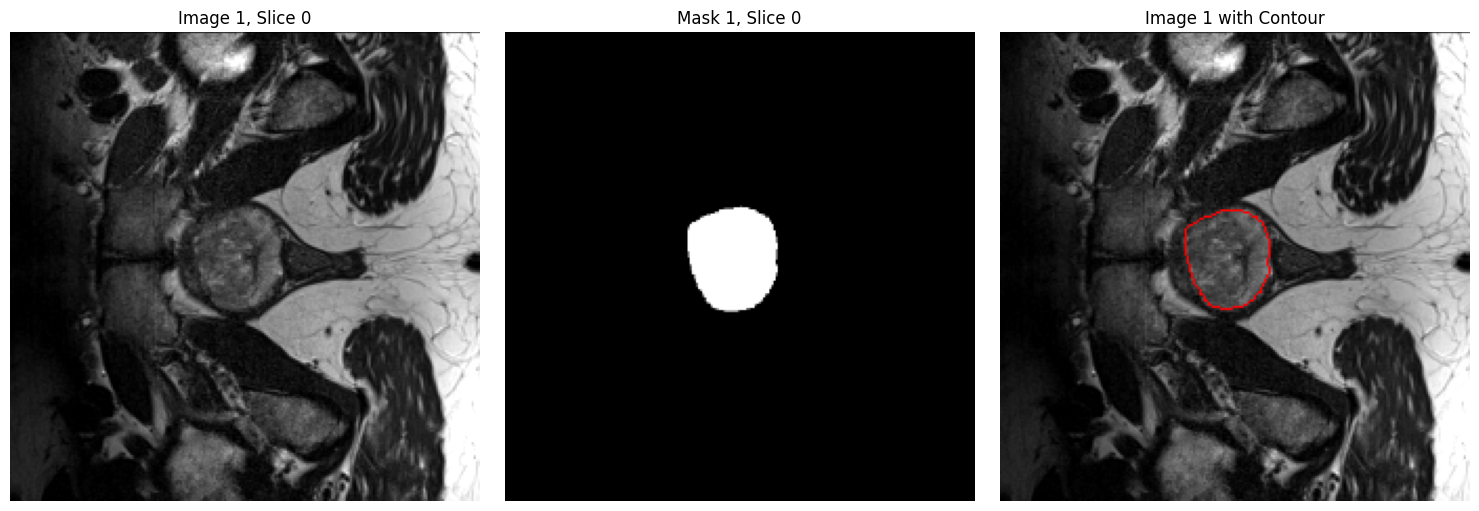

In [27]:
dataset = Dataset(image_dir, mask_dir)
test_img, test_mask = dataset.__getitem__(70)
test_img.max()
visualize_slices_with_contours([denormalize(test_img)], [test_mask], 0)

In [26]:
dataset.__len__()

250

## Processing Input

267


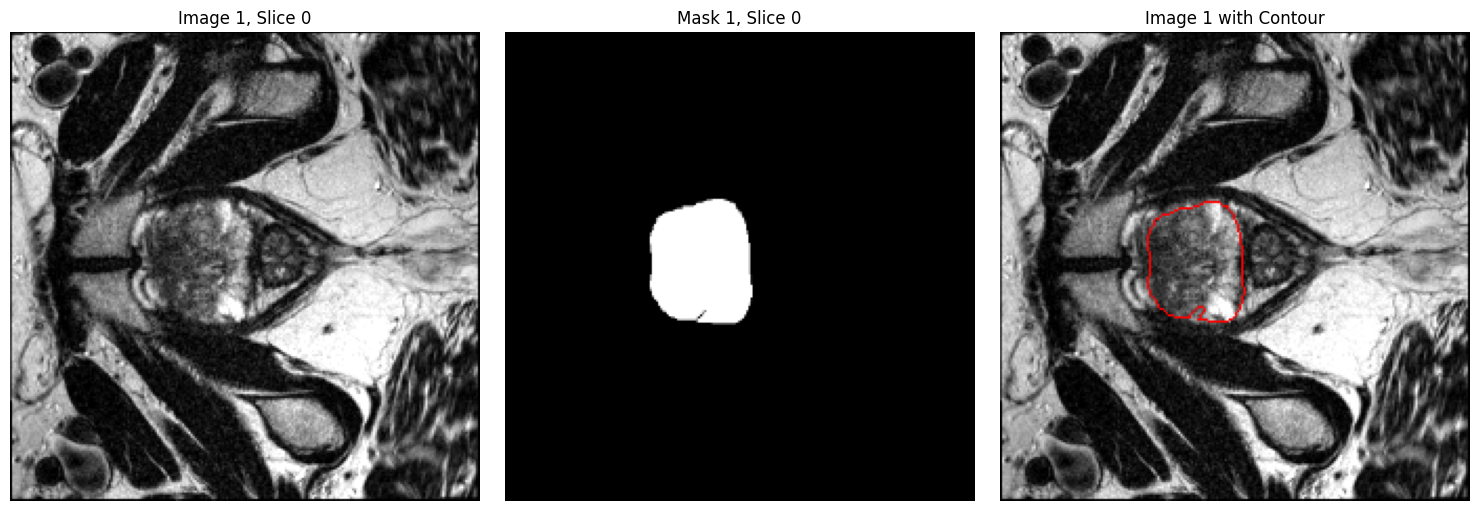

In [19]:
image_dir = '/content/drive/MyDrive/CV_MRI_Project_Folder/Processed_Prostate_Site_A_B_Data/Processed_Images/Site-B-BMC-Splited/train/mri_images/'
mask_dir = '/content/drive/MyDrive/CV_MRI_Project_Folder/Processed_Prostate_Site_A_B_Data/Processed_Images/Site-B-BMC-Splited/train/mri_masks/'

dataset = Dataset(image_dir, mask_dir)
print(dataset.__len__())
test_img, test_mask = dataset.__getitem__(250)
test_img.max()
visualize_slices_with_contours([denormalize(test_img)], [test_mask], 0)

In [10]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

def plot_image_mask_contour(image, mask):
    """
    Visualize an MRI image, its segmentation mask, and the contours derived from the mask.

    Parameters:
    - image: The MRI image as a NumPy array.
    - mask: The segmentation mask as a NumPy array.
    """
    # Convert mask to binary if it's not already
    binary_mask = (mask > 0).astype(np.uint8)

    # Find contours from the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create a copy of the image to draw contours on
    image_with_contours = np.copy(image)
    cv2.drawContours(image_with_contours, contours, -1, (0, 255, 0), 3)

    # Plotting the image, mask, and image with contours
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Segmentation Mask')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(image_with_contours, cmap='gray')
    plt.title('Image with Contours')
    plt.axis('off')

    plt.show()

# Model Training Module

In [11]:
def ensure_directory(directory_path):
    os.makedirs(directory_path, exist_ok=True)

def create_callbacks(base_path, backbone, site, epochs, learning_rate):
    version = datetime.now().strftime("%Y%m%d_%H%M%S")
    checkpoints_path = os.path.join(base_path, 'checkpoints', backbone, site)
    logs_path = os.path.join(base_path, 'logs', backbone, site)

    ensure_directory(checkpoints_path)
    ensure_directory(logs_path)

    filename = f'{backbone}_S_{site}_LR{str(learning_rate).replace(".", "")}_E{epochs}_{version}'
    checkpoint_filepath = os.path.join(checkpoints_path, f'{filename}.h5')
    log_filepath = os.path.join(logs_path, f'logs_{filename}.csv')

    callbacks = [
        ModelCheckpoint(checkpoint_filepath, monitor='val_loss', save_best_only=True, save_weights_only=True, mode='min'),
        EarlyStopping(monitor='val_loss', patience=3, verbose=1),
        CSVLogger(log_filepath, append=False)
    ]

    return callbacks, checkpoint_filepath


def save_model(base_path, site, backbone, model, epochs, learning_rate):
    version = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_directory = os.path.join(base_path, 'models', backbone, site)
    ensure_directory(model_directory)

    filename = f'{backbone}_S_{site}_LR{str(learning_rate).replace(".", "")}_E{epochs}_{version}.hdf5'
    model.save(os.path.join(model_directory, filename))

def plot_history(history):
    plt.figure(figsize=(30, 7))

    # Plot IOU Score
    plt.subplot(121)
    plt.plot(history.history['iou_score'], label='Train IOU Score')
    plt.plot(history.history['val_iou_score'], label='Validation IOU Score')
    plt.title('Model IOU Score')
    plt.xlabel('Epoch')
    plt.ylabel('IOU Score')
    plt.legend(loc='upper left')

    # Plot Loss
    plt.subplot(122)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper left')

    plt.show()

In [12]:
def evaluate_model(model, test_dataloader, model_weights_path, metrics):
    """
    Evaluate the model on the test dataset.

    Parameters:
    - model: The compiled Keras model to evaluate.
    - test_dataloader: The dataloader containing the test dataset.
    - model_weights_path: Path to the model weights to load.
    - metrics: List of metrics that the model was compiled with.

    Returns:
    - scores: The evaluation scores for each metric.
    """
    # Load the best model weights
    model.load_weights(model_weights_path)

    # Evaluate the model on the test dataset
    scores = model.evaluate(test_dataloader, steps=len(test_dataloader))

    # Print evaluation results
    print(f"Loss: {scores[0]}")
    for metric, value in zip(metrics, scores[1:]):
        print(f"mean {metric.__name__}: {value}")

    return scores

In [13]:
def get_preprocessing_fn(backbone_name):
    return sm.get_preprocessing(backbone_name)

def create_datasets_and_dataloaders(img_dir, mask_dir, backbone, batch_size=1, shuffle_train=True):
    # Get the preprocessing function for the specified backbone
    preprocess_input = get_preprocessing_fn(backbone)
    # Create datasets
    dataset = Dataset(img_dir, mask_dir, preprocessing=preprocess_input)
    # Create dataloaders
    dataloader = Dataloader(dataset, batch_size=batch_size, shuffle=shuffle_train)

    return dataloader


In [14]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from tensorflow.keras.optimizers import Adam
from datetime import datetime
import segmentation_models as sm


def train_and_evaluate_model(dataset, model_config, training_params):
    # Unpack the dataset and training parameters
    site = dataset['site']
    train_img_dir = dataset['train_img_dir']
    train_mask_dir = dataset['train_mask_dir']
    val_img_dir = dataset['val_img_dir']
    val_mask_dir = dataset['val_mask_dir']
    test_img_dir = dataset['test_img_dir']
    test_mask_dir = dataset['test_mask_dir']
    n_classes, activation, epochs, lr, batch_size, metrics, local_path = model_config.values()
    backbone = training_params['backbone']


    # DataLoader
    train_dataloader= create_datasets_and_dataloaders(train_img_dir, train_mask_dir, backbone, batch_size , shuffle_train=True)
    valid_dataloader= create_datasets_and_dataloaders(val_img_dir, val_mask_dir, backbone, batch_size , shuffle_train=False)
    test_dataloader= create_datasets_and_dataloaders(test_img_dir, test_mask_dir, backbone, batch_size , shuffle_train=False)

    # Model setup
    model = sm.Unet(backbone, encoder_weights='imagenet', classes=n_classes, activation=activation)
    model.compile(optimizer=Adam(lr), loss=sm.losses.DiceLoss() + (1 * sm.losses.BinaryFocalLoss()), metrics=metrics)

    # Callbacks
    callbacks, model_weights_path = create_callbacks(local_path, site, backbone, epochs, lr)

    # Training
    history = model.fit(train_dataloader,
                        validation_data=valid_dataloader,
                        epochs=epochs,
                        callbacks=callbacks,
                        steps_per_epoch=5, #len(train_dataloader),
                        validation_steps=3) #len(valid_dataloader))

    # Save model
    save_model(local_path, site, backbone, model, epochs, lr)

    # Plot history
    plot_history(history)

    # Evaluate
    evaluate_model(model, test_dataloader, model_weights_path, metrics)

    return model, history



In [15]:
local_path = '/content/drive/MyDrive/CV_MRI_Project_Folder/Processed_Prostate_Site_A_B_Data/Processed_Images/'

A_train_img_dir = local_path +'Site-A-RUNMC-Splited/train/mri_images/'
A_train_mask_dir = local_path +'Site-A-RUNMC-Splited/train/mri_masks/'
A_val_img_dir = local_path + 'Site-A-RUNMC-Splited/val/mri_images/'
A_val_mask_dir = local_path+'Site-A-RUNMC-Splited/val/mri_masks/'
A_test_img_dir = local_path+'Site-A-RUNMC-Splited/test/mri_images/'
A_test_mask_dir = local_path + 'Site-A-RUNMC-Splited/test/mri_masks/'

B_train_img_dir = local_path + 'Site-B-BMC-Splited/train/mri_images/'
B_train_mask_dir = local_path +'Site-B-BMC-Splited/train/mri_masks/'
B_val_img_dir = local_path + 'Site-B-BMC-Splited/val/mri_images/'
B_val_mask_dir = local_path + 'Site-B-BMC-Splited/val/mri_masks/'
B_test_img_dir = local_path + 'Site-B-BMC-Splited/test/mri_images/'
B_test_mask_dir = local_path + 'Site-B-BMC-Splited/test/mri_masks/'

In [12]:
model_config = {
    'n_classes': 1,
    'activation': 'sigmoid',
    'epochs': 2,
    'lr': 0.001,
    'batch_size': 2,
    'metrics': [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5)],
    'local_path': local_path +"Saved_Models/"#'/content/drive/MyDrive/CV_MRI_Project_Folder/Processed_Prostate_Site_A_B_Data/Processed_Images/',
}

dataset_A_info = {
    'site': 'Site_A' ,
    'train_img_dir': A_train_img_dir,
    'train_mask_dir': A_train_mask_dir,
    'val_img_dir': A_val_img_dir,
    'val_mask_dir':A_val_mask_dir,
    'test_img_dir': A_test_img_dir,
    'test_mask_dir': A_test_mask_dir
}
dataset_B_info = {
    'site': 'B' ,
    'train_img_dir': B_train_img_dir,
    'train_mask_dir': B_train_mask_dir,
    'val_img_dir': B_val_img_dir,
    'val_mask_dir':B_val_mask_dir,
    'test_img_dir': B_test_img_dir,
    'test_mask_dir': B_test_mask_dir
}

vgg19_training_params = {
    # Any additional training parameters
    'backbone': 'vgg19',

}
resnet50_training_params = {
    # Any additional training parameters
    'backbone': 'resnet50',

}
efficientnetb0_training_params = {
    # Any additional training parameters
    'backbone': 'efficientnetb0',

}


## Training Models on Site A Dataset

Epoch 1/2
5/5 [==============================] - 51s 9s/step - loss: 1.1500 - iou_score: 0.0450 - f1-score: 0.0859 - val_loss: 1.1158 - val_iou_score: 3.4970e-09 - val_f1-score: 3.4970e-09
Epoch 2/2
5/5 [==============================] - 42s 9s/step - loss: 1.0216 - iou_score: 0.0708 - f1-score: 0.1286 - val_loss: 1.0814 - val_iou_score: 0.0036 - val_f1-score: 0.0072


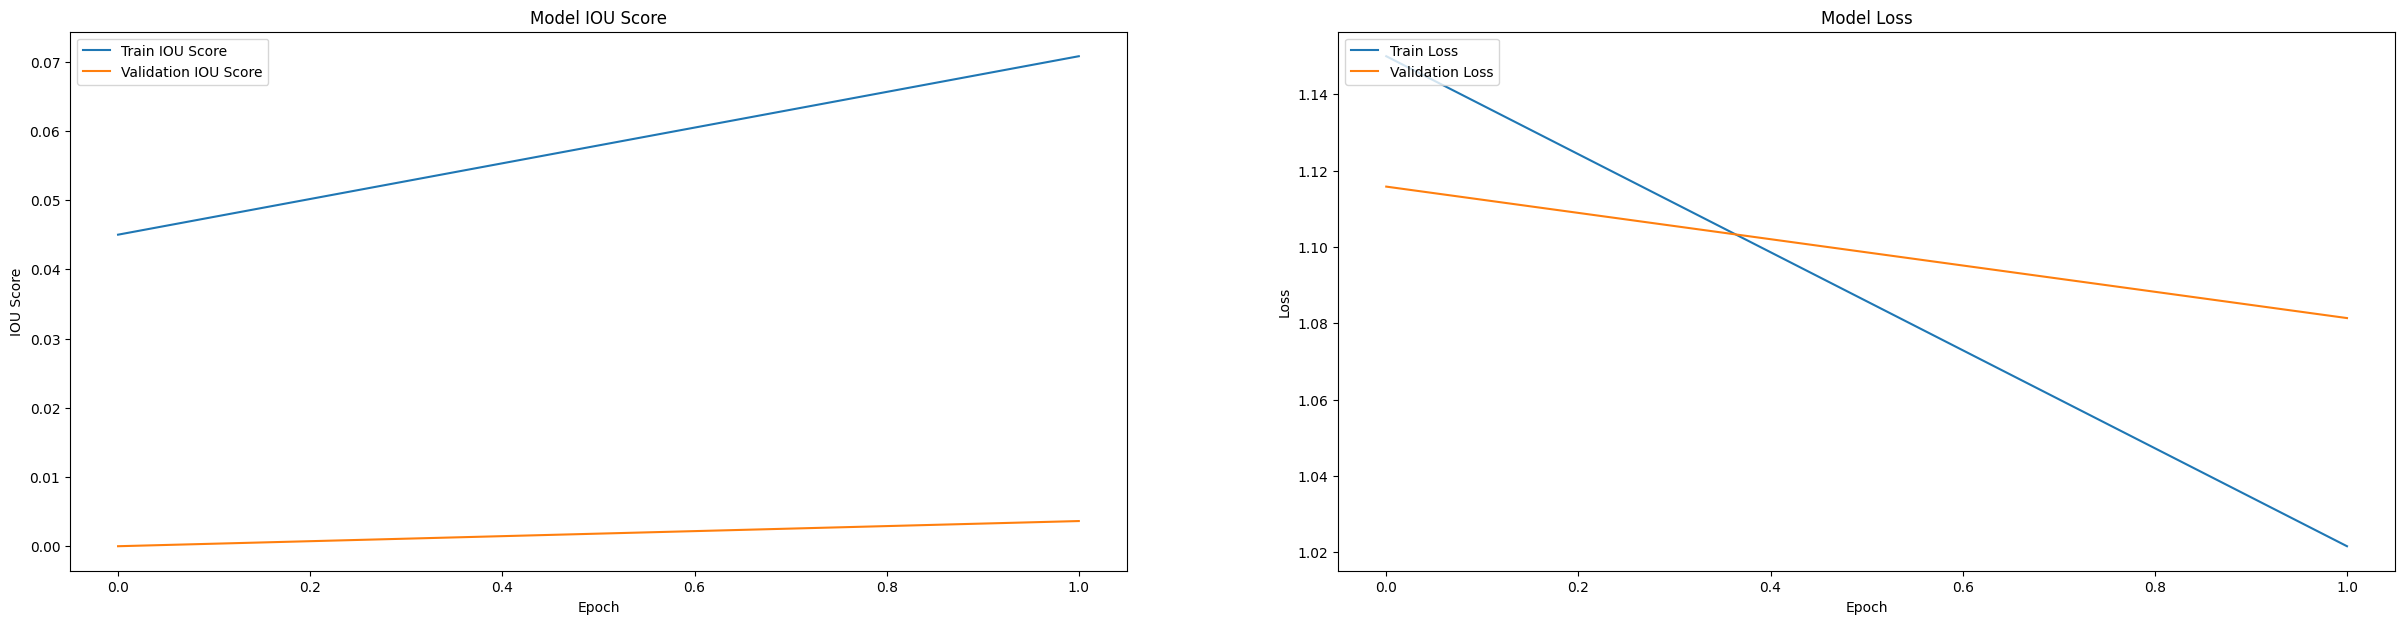

19/19 [==============================] - 34s 2s/step - loss: 1.0628 - iou_score: 0.0042 - f1-score: 0.0084
Loss: 1.0627703666687012
mean iou_score: 0.004220960196107626
mean f1-score: 0.008385582827031612


In [24]:
model1A, history1A = train_and_evaluate_model(dataset_A_info, model_config, vgg19_training_params)

In [ ]:
model2A, history2A = train_and_evaluate_model(dataset_A_info, model_config, resnet50_training_params)

In [ ]:
model3A, history3A = train_and_evaluate_model(dataset_A_info, model_config, efficientnetb0_training_params)

## Training Models on Site B Dataset

In [ ]:
model1B, history1B = train_and_evaluate_model(dataset_B_info, model_config, vgg19_training_params)

In [ ]:
model2B, history2B = train_and_evaluate_model(dataset_B_info, model_config, resnet50_training_params)

In [ ]:
model3B, history3B = train_and_evaluate_model(dataset_B_info, model_config, efficientnetb0_training_params)

## Hyperparameter Tuning

In [ ]:
import pandas as pd

file_name = 'my_logs_vgg19_A_with_faulty_preprocessing'
site = 'Site_A'
log_file_path = local_path+f'Training_Data/Saved_Models/logs/{site}/{file_name}.csv'
df = pd.read_csv(log_file_path)

In [ ]:
#checkking for different learning rate
#checking for number of epochs and early stopping
#detecting overfitting and underfitting
# Additional Considerations : Batch size


In [ ]:
import pandas as pd

# Example DataFrame to store metrics
metrics_df = pd.DataFrame(columns=['Site', 'Model', 'IOU Score', 'F-Score', 'Loss', 'Validation Loss'])

# Assuming these variables are filled with your actual metrics after each model training
site = 'A'
model_name = 'VGG19'
iou_score = 0.85
f_score = 0.87
loss = 0.1
val_loss = 0.12

# Append metrics for each model
metrics_df = metrics_df.append({
    'Site': site,
    'Model': model_name,
    'IOU Score': iou_score,
    'F-Score': f_score,
    'Loss': loss,
    'Validation Loss': val_loss
}, ignore_index=True)

# Repeat the append step for each model and site combination

# Example of how to find the best model based on IOU Score for site A
best_model_site_A = metrics_df[metrics_df['Site'] == 'A'].sort_values(by='IOU Score', ascending=False).iloc[0]
print(f"The best model for Site A based on IOU Score is: {best_model_site_A['Model']} with an IOU Score of {best_model_site_A['IOU Score']}")


In [9]:
import pandas as pd
import re
import os

def calculate_metric(df, column, func):
    """Calculate a metric if the column exists in the DataFrame."""
    return func(df[column]) if column in df.columns else None

def analyze_model_logs(base_path):
    """Analyze model logs and return a DataFrame with the results."""
    results_df = pd.DataFrame(columns=[
        'Site', 'Model', 'Learning Rate', 'Epochs',
        'Max Val IOU Score', 'Epoch Max Val IOU',
        'Max Val F-Score', 'Epoch Max Val F-Score',
        'Min Val Loss', 'Epoch Min Val Loss',
        'Mean Val IOU Score', 'Mean Val F-Score', 'File Path'])

    # Regular expression pattern for filename extraction
    pattern = r'logs_(?P<model>[a-zA-Z0-9]+)_S_(?P<site>[A-Z])_LR(?P<lr>\d+)_E(?P<epochs>\d+)'

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith('.csv'):
                file_path = os.path.join(root, file)


                # Extract information from filename
                match = re.match(pattern, file)
                if match:
                    print("file_path", file_path)
                    info = match.groupdict()
                    learning_rate = str(int(info['lr']) / 10**(len(info['lr']) - 1))

                    # Load the CSV file to calculate metrics
                    log_df = pd.read_csv(file_path)
                    actual_epochs = len(log_df)

                    # Use a helper function to calculate metrics and the epochs at which they occur
                    max_val_iou = calculate_metric(log_df, 'val_iou_score', pd.Series.max)
                    epoch_max_val_iou = log_df['val_iou_score'].idxmax() + 1 if 'val_iou_score' in log_df.columns else None
                    max_val_f1 = calculate_metric(log_df, 'val_f1-score', pd.Series.max)
                    epoch_max_val_f1 = log_df['val_f1-score'].idxmax() + 1 if 'val_f1-score' in log_df.columns else None
                    min_val_loss = calculate_metric(log_df, 'val_loss', pd.Series.min)
                    epoch_min_val_loss = log_df['val_loss'].idxmin() + 1 if 'val_loss' in log_df.columns else None
                    mean_val_iou = calculate_metric(log_df, 'val_iou_score', pd.Series.mean)
                    mean_val_f1 = calculate_metric(log_df, 'val_f1-score', pd.Series.mean)

                    # Append results to the DataFrame
                    results_df = results_df.append({
                        'Site': info['site'],
                        'Model': info['model'],
                        'Learning Rate': learning_rate,
                        'Epochs': actual_epochs,
                        'Max Val IOU Score': max_val_iou,
                        'Epoch Max Val IOU': epoch_max_val_iou,
                        'Max Val F-Score': max_val_f1,
                        'Epoch Max Val F-Score': epoch_max_val_f1,
                        'Min Val Loss': min_val_loss,
                        'Epoch Min Val Loss': epoch_min_val_loss,
                        'Mean Val IOU Score': mean_val_iou,
                        'Mean Val F-Score': mean_val_f1,
                        'File Path': file_path
                    }, ignore_index=True)

    return results_df



In [13]:
base_path = "/content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/"
results_df = analyze_model_logs(base_path)

# Optionally, save the results to a new CSV file for further analysis
results_df.to_csv("/content/drive/MyDrive/CV_MRI_Project_Folder/model_analysis_results.csv", index=False)

file_path /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/VGG19/logs_vgg19_S_A_LR00001_E50_NEarlyStopping.csv
file_path /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/VGG19/logs_vgg19_S_A_LR001_E50_YEarlyStopping_StoppedAtE32.csv
file_path /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/RESNET50/logs_resnet50_S_A_LR0001_E50_YEarlyStopping_StoppedAtE9.csv


<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


file_path /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/RESNET50/logs_resnet50_S_A_LR0001_E34_NEarlyStopping.csv


<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


file_path /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/RESNET50/logs_resnet50_S_A_LR00001_E50_NEarlyStopping.csv


<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = resul

file_path /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/EFFICIENTNETB0/logs_efficientnetb0_S_A_LR0001_E5_NEarlyStopped.csv
file_path /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/BEST_SELECTED/logs_efficientnetb0_S_A_LR0001_E13_NEarlyStopping_best.csv.csv
file_path /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/BEST_SELECTED/logs_resnet50_S_A_LR0001_E34_NEarlyStopping_best.csv
file_path /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/BEST_SELECTED/logs_vgg19_S_A_LR0001_E50_YEarlyStopping_StoppedAt34_best.csv
file_path /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_B/VGG19/logs_vgg19_S_B_LR001_E34_YEarlyStopping_StoppedAtE17.csv
file_path /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_B/VGG19/logs_vgg

<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
<ipython-input-9-f97a06bd927e>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


In [6]:
for root, dirs, files in os.walk(base_path):
  print(f"root {root}, dir {dirs}, files {files}  ")

root /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/, dir ['Site_A', 'Site_B'], files []  
root /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A, dir ['.ipynb_checkpoints', 'VGG19', 'RESNET50', 'EFFICIENTNETB0', 'BEST_SELECTED'], files []  
root /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/.ipynb_checkpoints, dir [], files []  
root /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/VGG19, dir ['.ipynb_checkpoints'], files ['logs_vgg19_S_A_LR00001_E50_NEarlyStopping.csv', 'logs_vgg19_S_A_LR001_E50_YEarlyStopping_StoppedAtE32.csv']  
root /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/VGG19/.ipynb_checkpoints, dir [], files []  
root /content/drive/MyDrive/CV_MRI_Project_Folder/Non_Normalized_Resized224/Saved_Models/logs/Site_A/RESNET50, dir [], files ['log

In [14]:
print(results_df)

   Site           Model Learning Rate Epochs  Max Val IOU Score  \
0     A           vgg19        0.0001     50           0.787969   
1     A           vgg19          0.01     32           0.514551   
2     A        resnet50         0.001      9           0.237014   
3     A        resnet50         0.001     34           0.827864   
4     A        resnet50        0.0001     50           0.840511   
5     A  efficientnetb0         0.001      5           0.185963   
6     A  efficientnetb0         0.001     13           0.843536   
7     A        resnet50         0.001     34           0.800318   
8     A           vgg19         0.001     34           0.748417   
9     B           vgg19          0.01     17           0.223725   
10    B           vgg19         0.001     22           0.495094   
11    B        resnet50         0.001     34           0.823872   
12    B        resnet50         0.001     31           0.818244   
13    B        resnet50        0.0001     34           0.81480



---



In [17]:
# Define backbones and their preprocessing functions
backbones = ['vgg19', 'resnet50', 'efficientnetb0']
preprocess_inputs = [sm.get_preprocessing(backbone) for backbone in backbones]

In [19]:
#Site A
# Dataset for train images
train_dataset_A = Dataset(
    A_train_img_dir,
    A_train_mask_dir,
    # preprocessing=get_preprocessing(preprocess_input1),
    # preprocessing= preprocess_inputs[0],
)

# Dataset for validation images
valid_dataset_A = Dataset(
    A_val_img_dir,
    A_val_mask_dir,
    # preprocessing=get_preprocessing(preprocess_input1),
    # preprocessing= preprocess_inputs[0],
)

# Initialize dataloaders
train_dataloader_A = Dataloader(train_dataset_A, batch_size=10, shuffle=True)
valid_dataloader_A = Dataloader(valid_dataset_A, batch_size=1, shuffle=False)


In [22]:
test_dataset_A = Dataset(
    A_test_img_dir,
    A_test_mask_dir,
    # preprocessing=get_preprocessing(preprocess_input1),
    # preprocessing= preprocess_inputs[0],
)

In [20]:
train_dataset_A.__len__()


250

In [21]:
valid_dataloader_A.__len__()

80

In [24]:
test_dataset_A.__len__()

39

In [25]:
# Dataset for train images
train_dataset_B = Dataset(
    B_train_img_dir,
    B_train_mask_dir,
    # preprocessing=preprocess_input2,
)

# Dataset for validation images
valid_dataset_B = Dataset(
    B_val_img_dir,
    B_val_mask_dir,
    # preprocessing=preprocess_input2,
)
test_dataset_B = Dataset(
    B_test_img_dir,
    B_test_mask_dir,
    # preprocessing=preprocess_input2,
)

print(train_dataset_B.__len__())
print(valid_dataset_B.__len__())
print(test_dataset_B.__len__())

# Initialize dataloaders
# train_dataloader_B = Dataloader(train_dataset_B, batch_size=BATCH_SIZE, shuffle=True)
# valid_dataloader_B = Dataloader(valid_dataset_B, batch_size=1, shuffle=False)

267
70
37


In [ ]:
# Define constants and configurations at the beginning
N_CLASSES = 1
ACTIVATION = 'sigmoid'
EPOCHS = 34
LEARNING_RATE = 0.0001
BATCH_SIZE = 10
BASE_PATH = "your_base_path_here"

In [ ]:
# Python
def process_mri_images(site_folder, threshold, main_folder_path, output_folder_path):
    folder_name = site_folder.split('/')[-1]
    files = os.listdir(site_folder)
    mri_files = [f for f in files if f.endswith('.nii.gz') and ('segmentation' not in f.lower())]
    low_info_slices_dict = {}

    for mri_file in mri_files:
        mri_path = os.path.join(site_folder, mri_file)
        segmentation_path = os.path.join(site_folder, f"{mri_file.split('.')[0]}_segmentation.nii.gz")

        mri_img = nib.load(mri_path).get_fdata()
        seg_img = nib.load(segmentation_path).get_fdata().astype(np.uint8)

        # Set segmentation mask to binary
        seg_img[seg_img > 0] = 1

        # Calculate slice information
        slice_information = np.sum(seg_img, axis=(0, 1)) / (seg_img.shape[0] * seg_img.shape[1])

        # Identify slices with less than the specified threshold
        low_info_slices = np.where(slice_information < threshold)[0]

        # Remove the identified low-info slices
        filtered_mri_img = np.delete(mri_img, low_info_slices, axis=2)
        filtered_seg_img = np.delete(seg_img, low_info_slices, axis=2)

        # Save low-info slice indices to dictionary
        low_info_slices_dict[os.path.join(folder_name, mri_file)] = [mri_img.shape, filtered_mri_img.shape, low_info_slices.tolist()]

        # Save the modified 3D image
        np.save(os.path.join(output_folder_path, folder_name, 'mri_images', f"{mri_file.split('.')[0]}.npy"), filtered_mri_img)
        np.save(os.path.join(output_folder_path, folder_name, 'mri_masks', f"{mri_file.split('.')[0]}-seg.npy"), filtered_seg_img)

    return low_info_slices_dict

# Constants
THRESHOLD = 0.01
MAIN_FOLDER_PATH = '/content/drive/MyDrive/Prostate_Data/'
OUTPUT_FOLDER_PATH = '/content/drive/MyDrive/Processed_Prostate_Data/Non_Normalized_Data/'

# Process MRI images
site_folders = [f.path for f in os.scandir(MAIN_FOLDER_PATH) if f.is_dir()]
for site_folder in site_folders:
    low_info_slices_dict = process_mri_images(site_folder, THRESHOLD, MAIN_FOLDER_PATH, OUTPUT_FOLDER_PATH)

In [ ]:
# Python
def split_data(input_folder, output_folder, seed=42, ratio=(0.7, 0.2, 0.1)):
    splitfolders.ratio(input_folder, output=output_folder, seed=seed, ratio=ratio, group_prefix=None)

# Constants
INPUT_BASE_PATH = '/content/drive/MyDrive/Processed_Prostate_Data/Non_Normalized_Data/'
OUTPUT_BASE_PATH = '/content/drive/MyDrive/Processed_Prostate_Data/Non_Normalized_Final_Data/'

# Sites
sites = ['Site-A-RUNMC', 'Site-B-BMC']

# Split data for each site
for site in sites:
    input_folder = os.path.join(INPUT_BASE_PATH, site)
    output_folder = os.path.join(OUTPUT_BASE_PATH, f'{site}-Splited')
    split_data(input_folder, output_folder)

In [ ]:
# Define helper functions
def plot_contour(single_img, seg_img, slice_index):
    binary_mask = (seg_img[:,:,slice_index] > 0).astype(np.uint8)
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    plt.title('Mask Boundary Overlay')
    plt.imshow(single_img[:,:,slice_index], cmap='gray')
    plt.contour(binary_mask, colors='green', linewidths=1)
    plt.show()

def plot_single_img_mask_contour(img, mask, slice_index):
    plt.figure(figsize=(10,4))
    plt.subplot(131)
    plt.imshow(img[:,:,slice_index], cmap='gray')
    plt.title('Image')
    plt.subplot(132)
    plt.imshow(mask[:,:,slice_index])
    plt.title('Mask')
    plt.subplot(133)
    plot_contour(img, mask, slice_index )
    plt.show()

def plot_img_contour(ax, single_img, seg_img, slice_index, i):
    binary_mask = (seg_img[:, :, slice_index] > 0).astype(np.uint8)
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    ax[0].imshow(single_img[:, :, slice_index], cmap='gray')
    ax[0].set_title(f'Image {i + 1}')
    ax[1].imshow(seg_img[:, :, slice_index], cmap='gray')
    ax[1].set_title(f'Mask {i + 1}')
    ax[2].imshow(single_img[:, :, slice_index], cmap='gray')
    ax[2].contour(binary_mask, colors='green', linewidths=1)
    ax[2].set_title(f'Mask Overlay {i + 1}')

def multi_image_view(image_list, mask_list, slice_indices):
    num_images = len(image_list)
    fig, axes = plt.subplots(nrows=num_images, ncols=3, figsize=(15, 5 * num_images))
    for i in range(num_images):
        plot_img_contour(axes[i], image_list[i], mask_list[i], slice_indices[i], i)
    plt.tight_layout()
    plt.show()

def convert_to_rgb(image):
    rgb_image = np.stack((image,) * 3, axis=-1)
    return rgb_image

# Define paths for Site A and Site B datasets
local_path = '/content/drive/MyDrive/Non_Normalized_Resized224/'

A_train_img_dir = local_path +'Site-A-RUNMC-Splited/train/mri_images/'
A_train_mask_dir = local_path +'Site-A-RUNMC-Splited/train/mri_masks/'
A_val_img_dir = local_path + 'Site-A-RUNMC-Splited/val/mri_images/'
A_val_mask_dir = local_path+'Site-A-RUNMC-Splited/val/mri_masks/'
A_test_img_dir = local_path+'Site-A-RUNMC-Splited/test/mri_images/'
A_test_mask_dir = local_path + 'Site-A-RUNMC-Splited/test/mri_masks/'

B_train_img_dir = local_path + 'Site-B-BMC-Splited/train/mri_images/'
B_train_mask_dir = local_path +'Site-B-BMC-Splited/train/mri_masks/'
B_val_img_dir = local_path + 'Site-B-BMC-Splited/val/mri_images/'
B_val_mask_dir = local_path + 'Site-B-BMC-Splited/val/mri_masks/'
B_test_img_dir = local_path + 'Site-B-BMC-Splited/test/mri_images/'
B_test_mask_dir = local_path + 'Site-B-BMC-Splited/test/mri_masks/'

# Define Dataset and Dataloader classes
class Dataset:
    def __init__(self, images_dir, masks_dir, preprocessing=None):
        self.images_fps = [os.path.join(images_dir, image_id) for image_id in sorted(os.listdir(images_dir))]
        self.masks_fps = [os.path.join(masks_dir, mask_id) for mask_id in sorted(os.listdir(masks_dir))]
        self.preprocessing = preprocessing

    def __getitem__(self, idx):
        image = np.load(self.images_fps[idx]).astype(np.float32)
        mask = np.load(self.masks_fps[idx]).astype(np.float32)
        if self.preprocessing:
            image = self.preprocessing(image)
        return image, mask

    def __len__(self):
        return len(self.images_fps)

class Dataloader(keras.utils.Sequence):
    def __init__(self, dataset, batch_size=1, shuffle=False):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(dataset))
        self.on_epoch_end()

    def __getitem__(self, i):
        start = i * self.batch_size
        stop = (i + 1) * self.batch_size
        data = [self.dataset[j] for j in range(start, stop)]
        batch = [np.stack(samples, axis=0) for samples in zip(*data)]
        return batch

    def __len__(self):
        return len(self.indexes) // self.batch_size

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [ ]:
model1, history1A = train_and_evaluate_model(BACKBONE1, 'A', preprocess_input1, local_path, epoch, LR, A_train_img_dir, A_train_mask_dir, A_val_img_dir, A_val_mask_dir, A_test_img_dir, A_test_mask_dir)
model1, history1B = train_and_evaluate_model(BACKBONE1, 'B', preprocess_input1, local_path, epoch, LR, B_train_img_dir, B_train_mask_dir, B_val_img_dir, B_val_mask_dir, B_test_img_dir, B_test_mask_dir)
model2, history2A = train_and_evaluate_model(BACKBONE2, 'A', preprocess_input2, local_path, epoch, LR, A_train_img_dir, A_train_mask_dir, A_val_img_dir, A_val_mask_dir, A_test_img_dir, A_test_mask_dir)
model2, history2B = train_and_evaluate_model(BACKBONE2, 'B', preprocess_input2, local_path, epoch, LR, B_train_img_dir, B_train_mask_dir, B_val_img_dir, B_val_mask_dir, B_test_img_dir, B_test_mask_dir)
model3, history3A = train_and_evaluate_model(BACKBONE3, 'A', preprocess_input3, local_path, epoch, LR, A_train_img_dir, A_train_mask_dir, A_val_img_dir, A_val_mask_dir, A_test_img_dir, A_test_mask_dir)
model3, history3B = train_and_evaluate_model(BACKBONE3, 'B', preprocess_input3, local_path, epoch, LR, B_train_img_dir, B_train_mask_dir, B_val_img_dir, B_val_mask_dir, B_test_img_dir, B_test_mask_dir)

In [ ]:
import keras
import segmentation_models as sm

# Define common parameters
n_classes = 1
activation = 'sigmoid'
epoch = 34
LR = 0.0001
optim = keras.optimizers.Adam(LR)
BATCH_SIZE = 10

# Define loss and metrics
dice_loss = sm.losses.DiceLoss()
focal_loss = sm.losses.BinaryFocalLoss()
total_loss = dice_loss + (1 * focal_loss)
metrics = [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5)]

# Define backbones and their preprocessing functions
backbones = ['vgg19', 'resnet50', 'efficientnetb0']
preprocess_inputs = [sm.get_preprocessing(backbone) for backbone in backbones]

# Define paths for Site A and Site B datasets
A_train_img_dir = ...
A_train_mask_dir = ...
A_val_img_dir = ...
A_val_mask_dir = ...
A_test_img_dir = ...
A_test_mask_dir = ...

B_train_img_dir = ...
B_train_mask_dir = ...
B_val_img_dir = ...
B_val_mask_dir = ...
B_test_img_dir = ...
B_test_mask_dir = ...

# Define local path for saving models and logs
local_path = ...

# Define function for training and evaluating model
def train_and_evaluate_model(backbone, site, preprocess_input, local_path, epoch, lr, train_img_dir, train_mask_dir, val_img_dir, val_mask_dir, test_img_dir, test_mask_dir):
    # Create model
    model = sm.Unet(backbone, classes=n_classes, activation=activation, encoder_weights='imagenet')
    model.compile(optim, total_loss, metrics)

    # Create callbacks
    callbacks = create_callbacks(local_path = local_path, site= site, backbone= backbone, epoch=epoch, lr=lr)

    # Create datasets
    train_dataset = Dataset(train_img_dir, train_mask_dir, preprocessing=preprocess_input)
    valid_dataset = Dataset(val_img_dir, val_mask_dir, preprocessing=preprocess_input)

    # Initialize dataloaders
    train_dataloader = Dataloader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    valid_dataloader = Dataloader(valid_dataset, batch_size=1, shuffle=False)

    # Train model
    history = model.fit_generator(
        train_dataloader,
        steps_per_epoch=len(train_dataloader),
        epochs=epoch,
        callbacks=callbacks,
        validation_data=valid_dataloader,
        validation_steps=len(valid_dataloader),
    )

    # Save model
    save_model(local_path = local_path, site = site, backbone = backbone , model = model, epoch = epoch, lr=lr)

    # Plot history
    plot_history(history= history)

    # Evaluate model
    test_dataset = Dataset(test_img_dir, test_mask_dir, preprocessing=preprocess_input)
    test_dataloader = Dataloader(test_dataset, batch_size=1, shuffle=False)

    # Load best weights
    model.load_weights(local_path+f'Saved_Models/callbacks/Site_{site}/{backbone}_model_{site}_{epoch}epoch_LR{str(lr).replace(".","")}.h5')

    # Use evaluate instead of deprecated evaluate_generator
    scores = model.evaluate(test_dataloader)

    print("Loss: {:.5}".format(scores[0]))
    for metric, value in zip(metrics, scores[1:]):
        print("mean {}: {:.5}".format(metric.__name__, value))

    return model, history

# Train and evaluate models for each backbone and site
for backbone, preprocess_input in zip(backbones, preprocess_inputs):
    model, history = train_and_evaluate_model(backbone, 'A', preprocess_input, local_path, epoch, LR, A_train_img_dir, A_train_mask_dir, A_val_img_dir, A_val_mask_dir, A_test_img_dir, A_test_mask_dir)
    model, history = train_and_evaluate_model(backbone, 'B', preprocess_input, local_path, epoch, LR, B_train_img_dir, B_train_mask_dir, B_val_img_dir, B_val_mask_dir, B_test_img_dir, B_test_mask_dir)

In [ ]:
def train_and_evaluate_model(backbone, site, preprocess_input, local_path, epoch, lr, train_img_dir, train_mask_dir, val_img_dir, val_mask_dir, test_img_dir, test_mask_dir):
    # Create model
    model = sm.Unet(backbone, classes=n_classes, activation=activation, encoder_weights='imagenet')
    model.compile(optim, total_loss, metrics)

    # Create callbacks
    callbacks = create_callbacks(local_path = local_path, site= site, backbone= backbone, epoch=epoch, lr=lr)

    # Create datasets
    train_dataset = Dataset(train_img_dir, train_mask_dir, preprocessing=preprocess_input)
    valid_dataset = Dataset(val_img_dir, val_mask_dir, preprocessing=preprocess_input)

    # Initialize dataloaders
    train_dataloader = Dataloader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    valid_dataloader = Dataloader(valid_dataset, batch_size=1, shuffle=False)

    # Train model
    history = model.fit_generator(
        train_dataloader,
        steps_per_epoch=len(train_dataloader),
        epochs=epoch,
        callbacks=callbacks,
        validation_data=valid_dataloader,
        validation_steps=len(valid_dataloader),
    )

    # Save model
    save_model(local_path = local_path, site = site, backbone = backbone , model = model, epoch = epoch, lr=lr)

    # Plot history
    plot_history(history= history)

    # Evaluate model
    test_dataset = Dataset(test_img_dir, test_mask_dir, preprocessing=preprocess_input)
    test_dataloader = Dataloader(test_dataset, batch_size=1, shuffle=False)

    # Load best weights
    model.load_weights(local_path+f'Saved_Models/callbacks/Site_{site}/{backbone}_model_{site}_{epoch}epoch_LR{str(lr).replace(".","")}.h5')

    # Use evaluate instead of deprecated evaluate_generator
    scores = model.evaluate(test_dataloader)

    print("Loss: {:.5}".format(scores[0]))
    for metric, value in zip(metrics, scores[1:]):
        print("mean {}: {:.5}".format(metric.__name__, value))

    return model, history


In [ ]:
def train_and_evaluate_model(backbone,
                             site,
                             activation,
                             preprocess_input,
                             local_path,
                             epoch, lr,
                             train_img_dir,
                             train_mask_dir,
                             val_img_dir,
                             val_mask_dir,
                             test_img_dir,
                             test_mask_dir):
    # Create model
    model = sm.Unet(backbone, classes=n_classes, activation=activation, encoder_weights='imagenet')
    model.compile(optim, total_loss, metrics)

    # Create callbacks
    callbacks = create_callbacks(local_path = local_path, site= site, backbone= backbone, epoch=epoch, lr=lr)

    # Create datasets
    train_dataset = Dataset(train_img_dir, train_mask_dir, preprocessing=preprocess_input)
    valid_dataset = Dataset(val_img_dir, val_mask_dir, preprocessing=preprocess_input)

    # Initialize dataloaders
    train_dataloader = Dataloader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    valid_dataloader = Dataloader(valid_dataset, batch_size=1, shuffle=False)

    # Train model
    history = model.fit_generator(
        train_dataloader,
        steps_per_epoch=len(train_dataloader),
        epochs=epoch,
        callbacks=callbacks,
        validation_data=valid_dataloader,
        validation_steps=len(valid_dataloader),
    )

    # Save model
    save_model(local_path = local_path, site = site, backbone = backbone , model = model, epoch = epoch, lr=lr)

    # Plot history
    plot_history(history= history)

    # Evaluate model
    test_dataset = Dataset(test_img_dir, test_mask_dir, preprocessing=preprocess_input)
    test_dataloader = Dataloader(test_dataset, batch_size=1, shuffle=False)

    # Load best weights
    model.load_weights(local_path+f'Saved_Models/callbacks/Site_{site}/{backbone}_model_{site}_{epoch}epoch_LR{str(lr).replace(".","")}.h5')

    # Use evaluate instead of deprecated evaluate_generator
    scores = model.evaluate(test_dataloader)

    print("Loss: {:.5}".format(scores[0]))
    for metric, value in zip(metrics, scores[1:]):
        print("mean {}: {:.5}".format(metric.__name__, value))

    return model, history